In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training rows: 9120
Validation checkpoints: 91
Steps per epoch: 1824
Epochs: 5


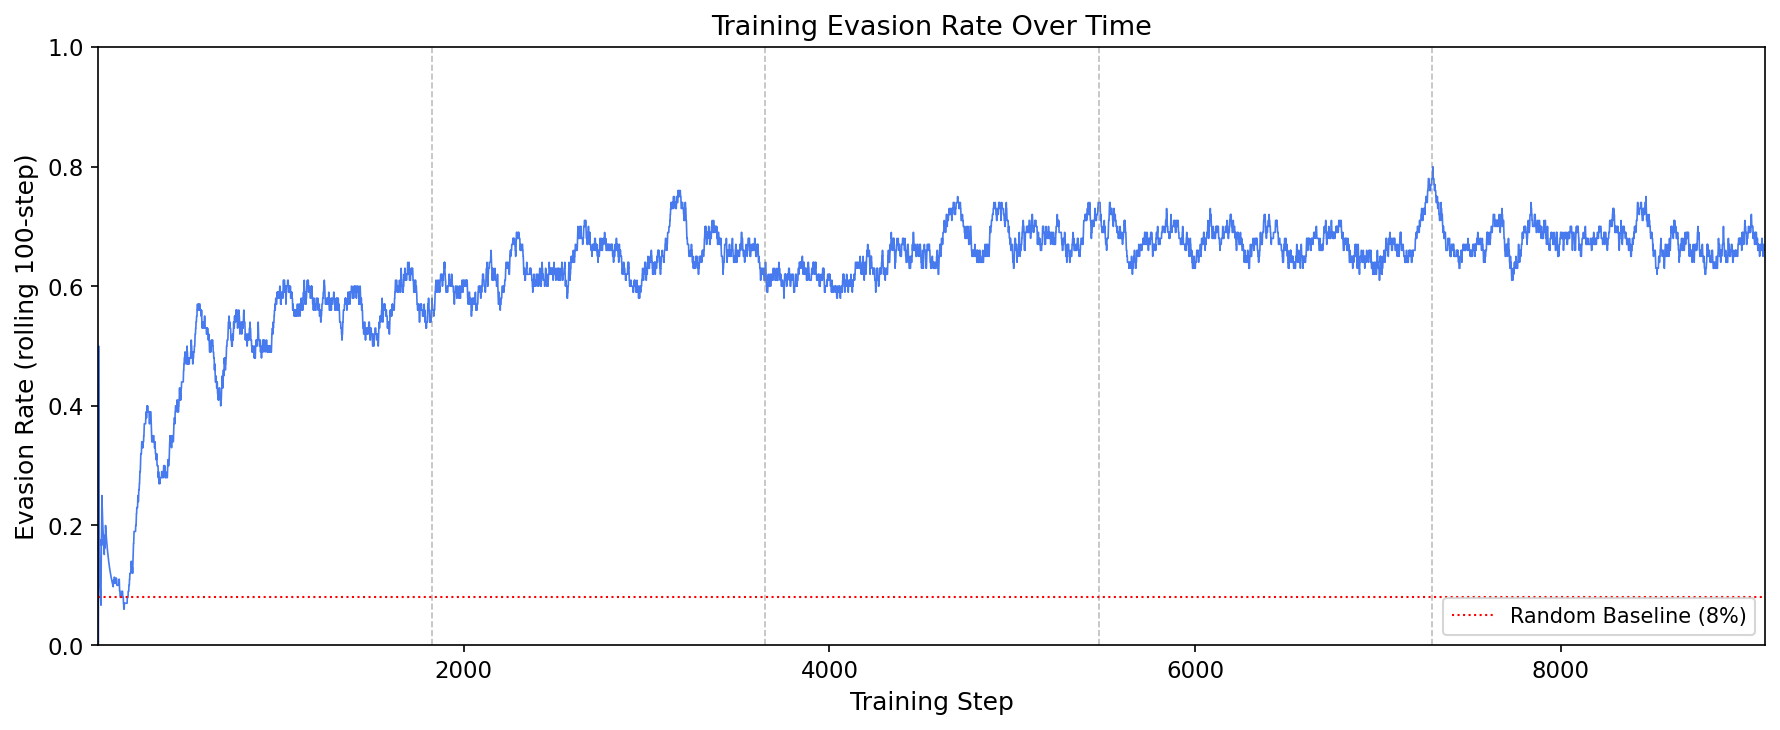

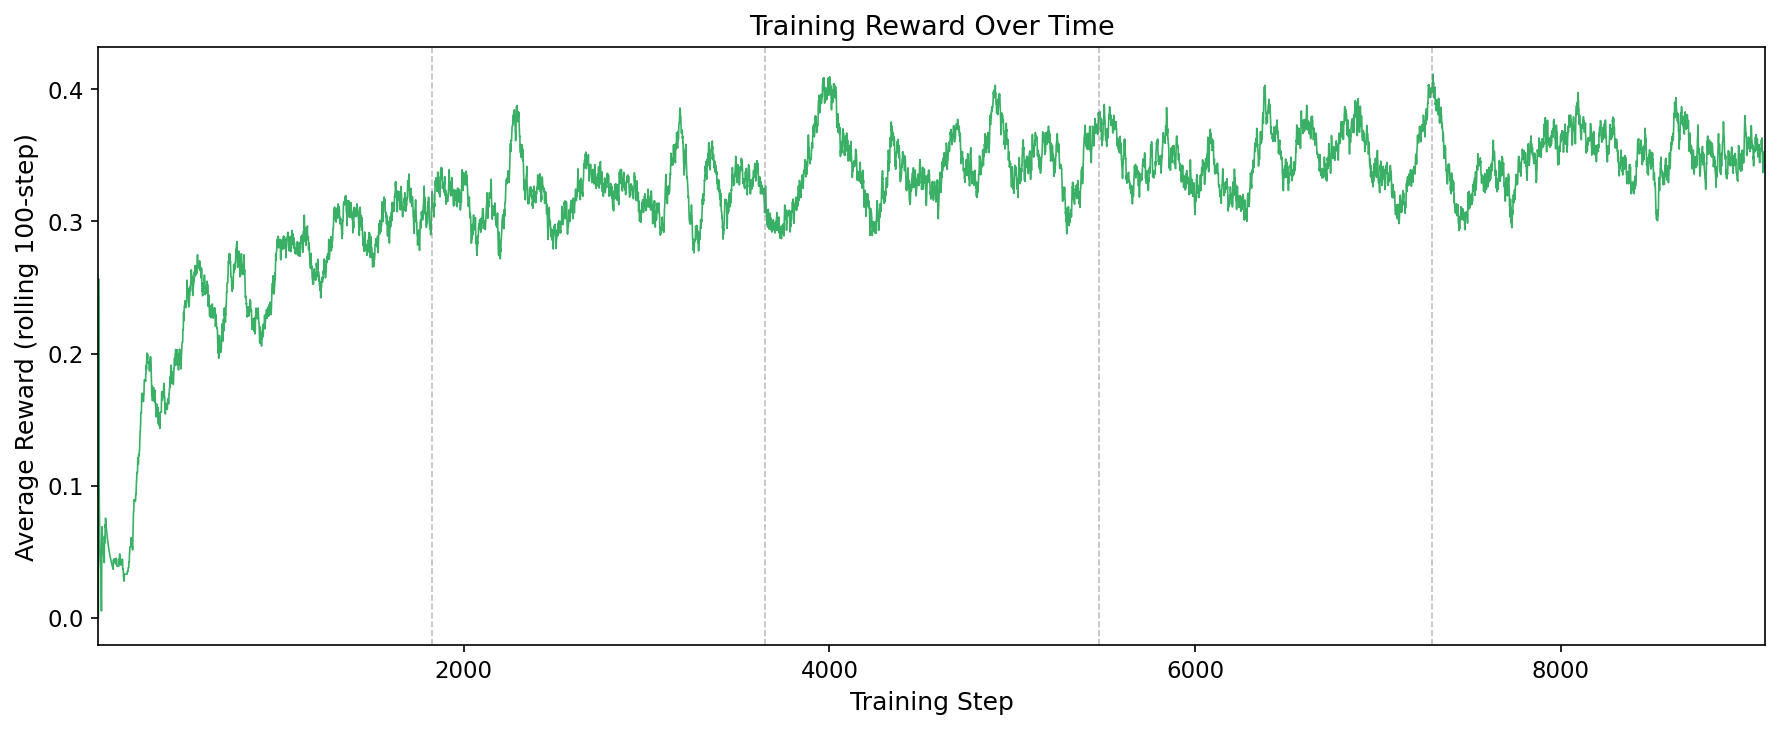

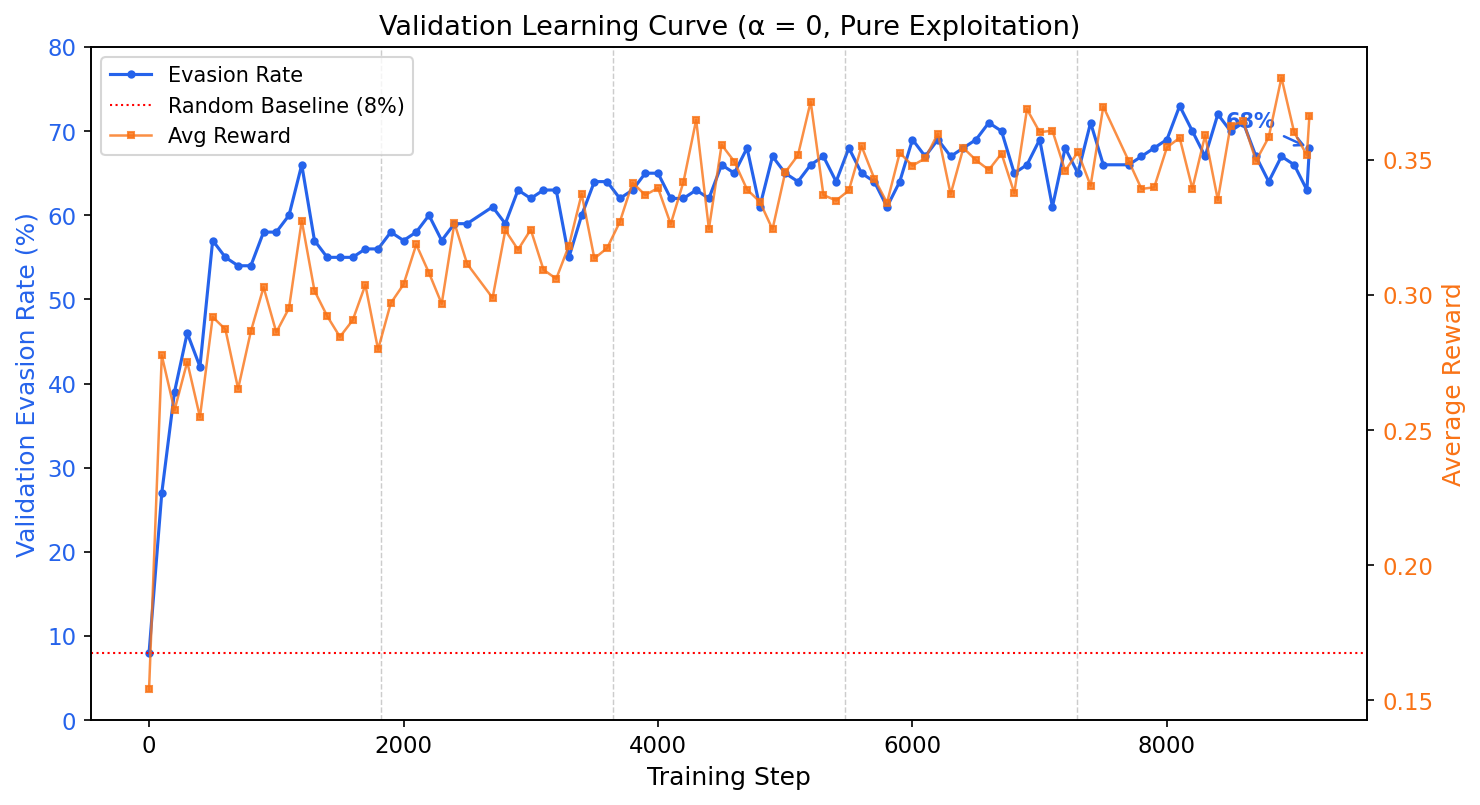

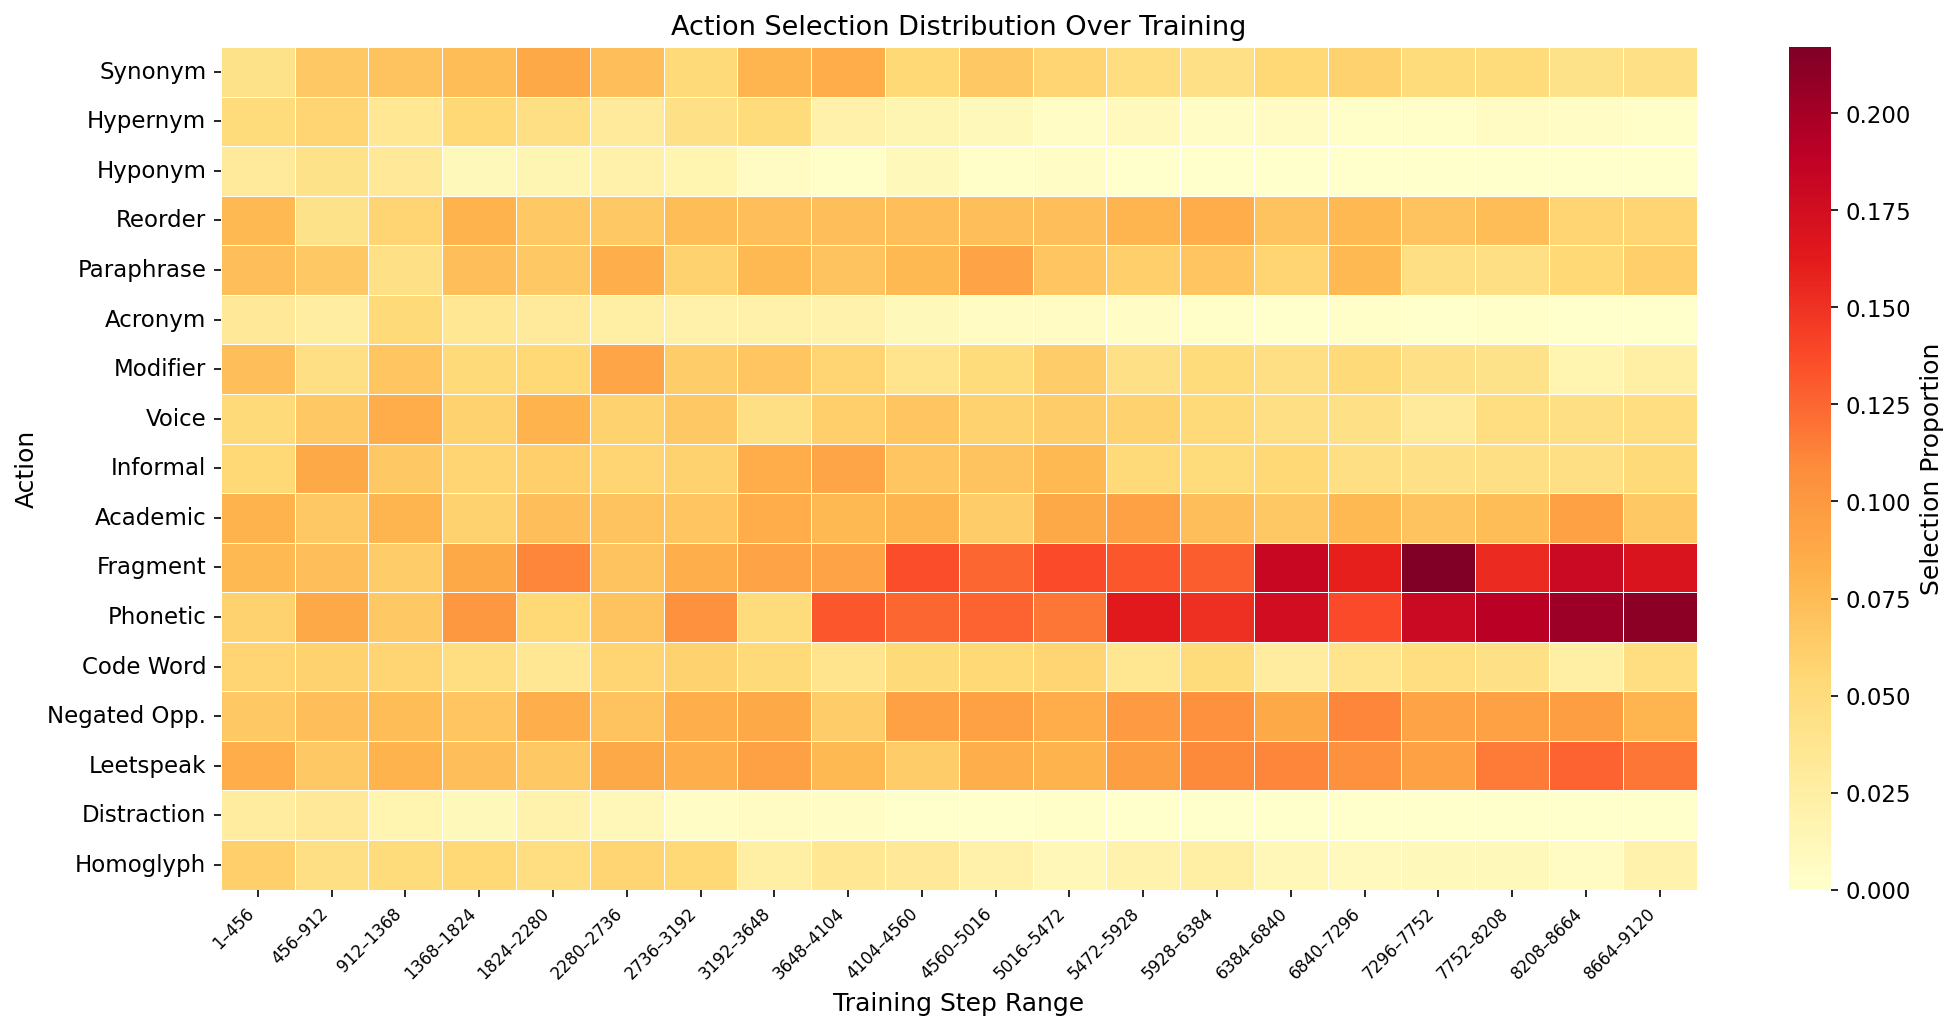

/tmp/ipykernel_44391/530987520.py:217: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 17)


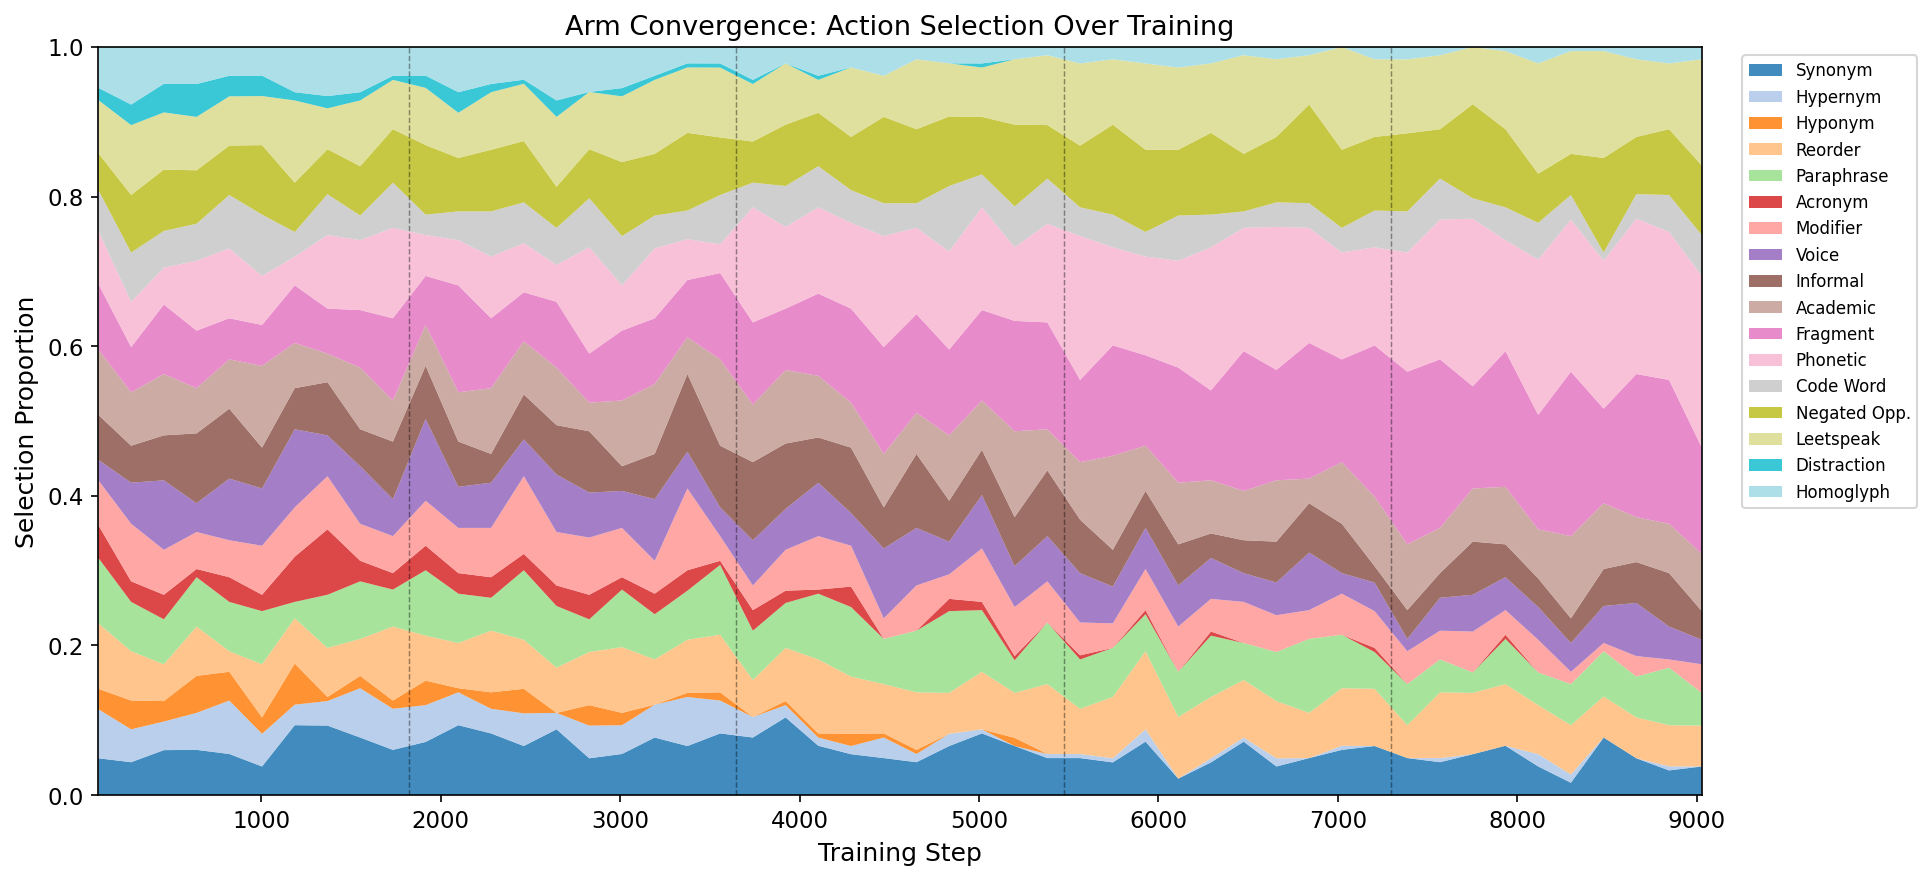

Final Action Proportions (End of Training):
---------------------------------------------
Phonetic                       :  22.95%
Leetspeak                      :  14.21%
Fragment                       :  14.21%
Negated Opp.                   :   9.29%
Academic                       :   7.65%
Code Word                      :   5.46%
Reorder                        :   5.46%
Paraphrase                     :   4.37%
Synonym                        :   3.83%
Modifier                       :   3.83%
Informal                       :   3.83%
Voice                          :   3.28%
Homoglyph                      :   1.64%
Acronym                        :   0.00%
Hypernym                       :   0.00%
Hyponym                        :   0.00%
Distraction                    :   0.00%



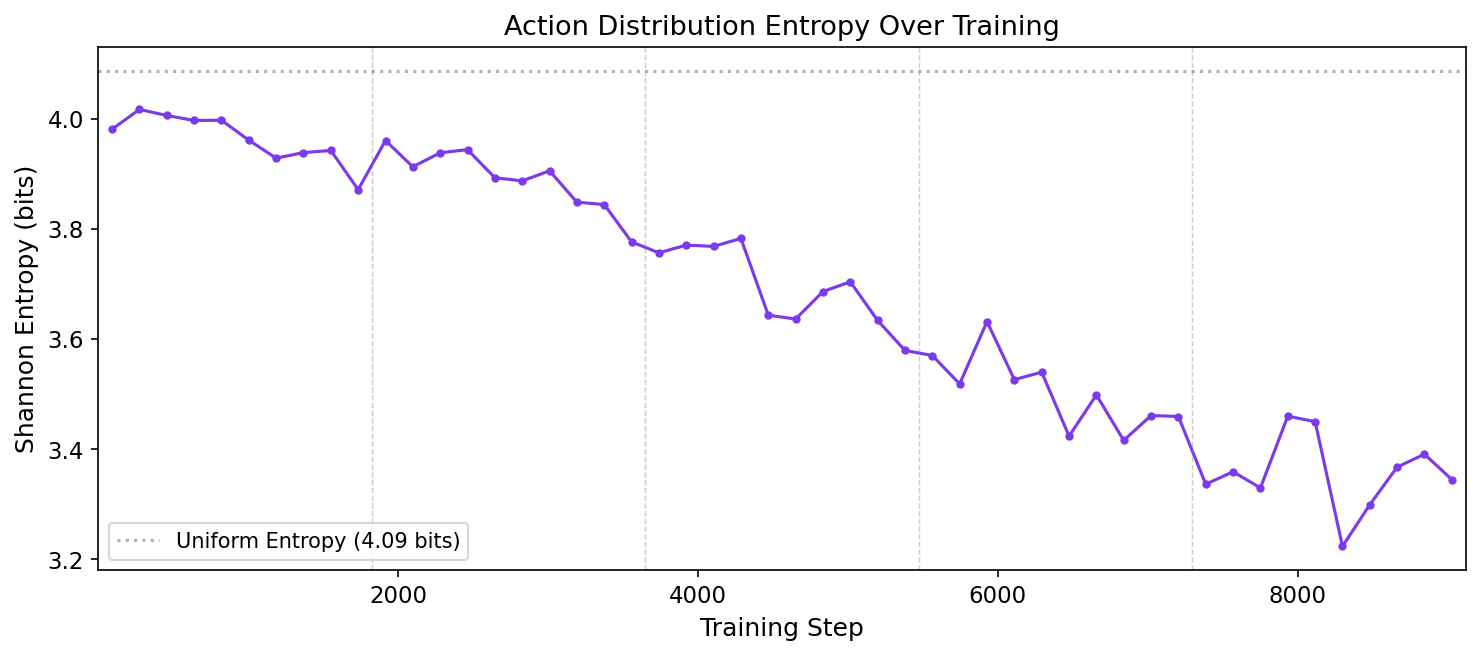

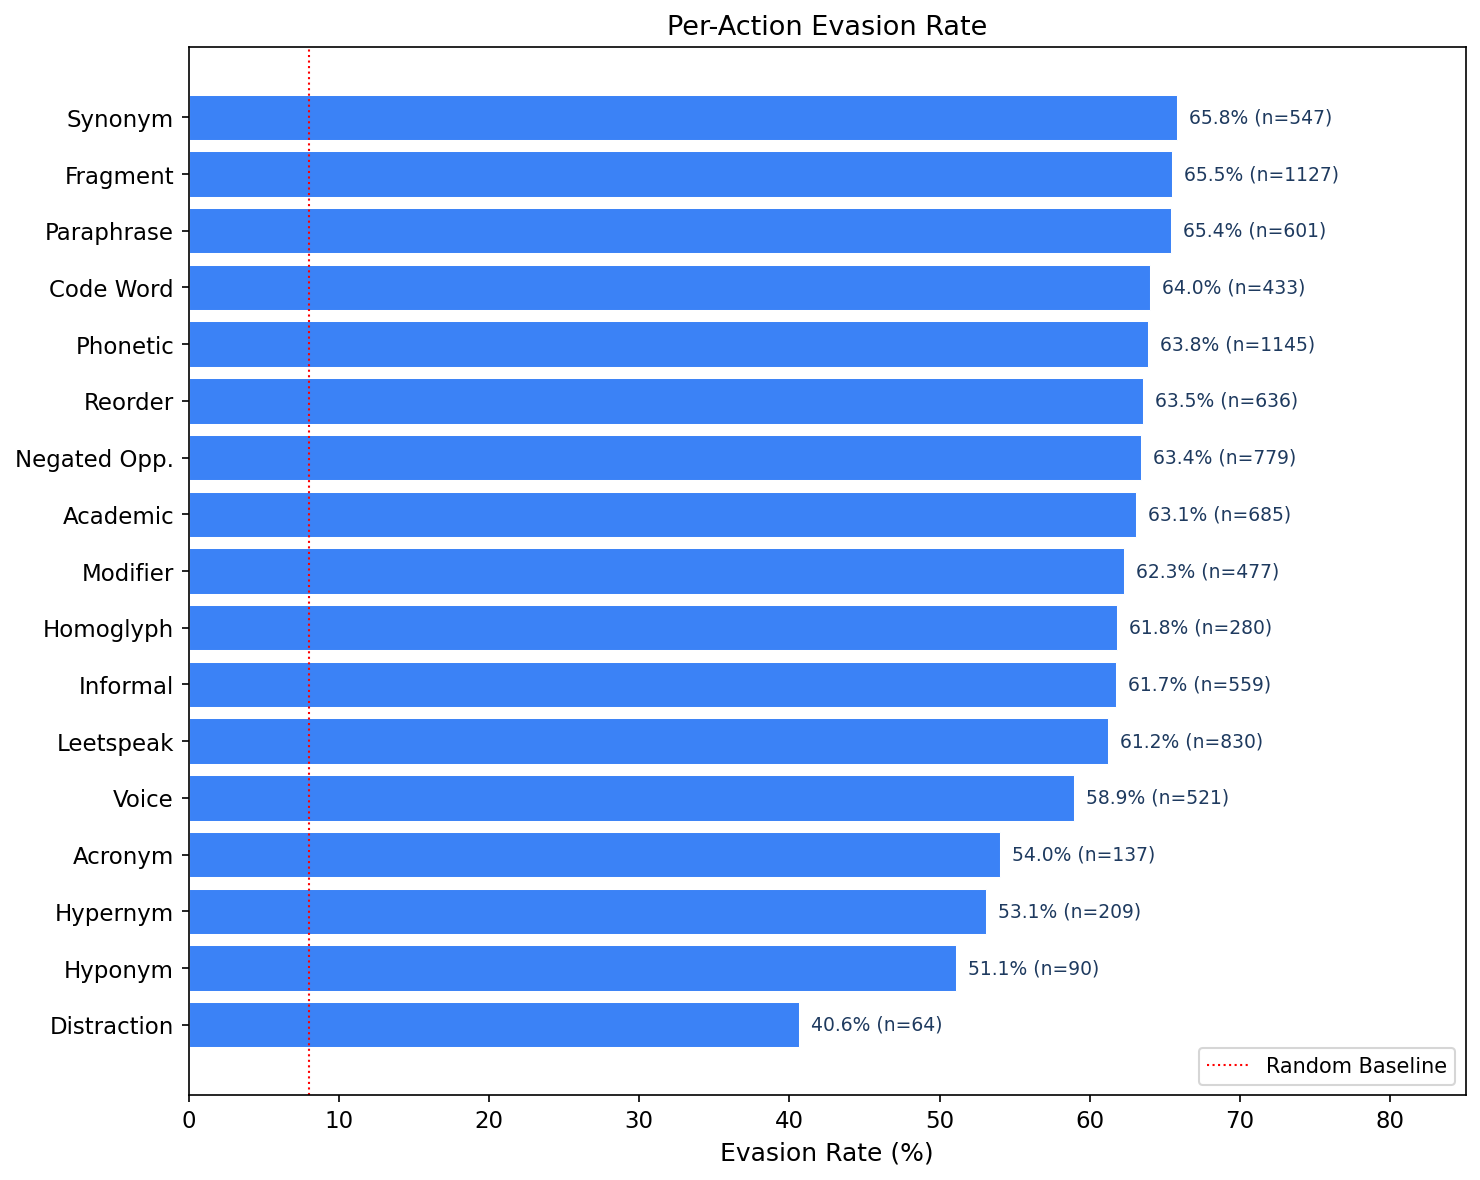

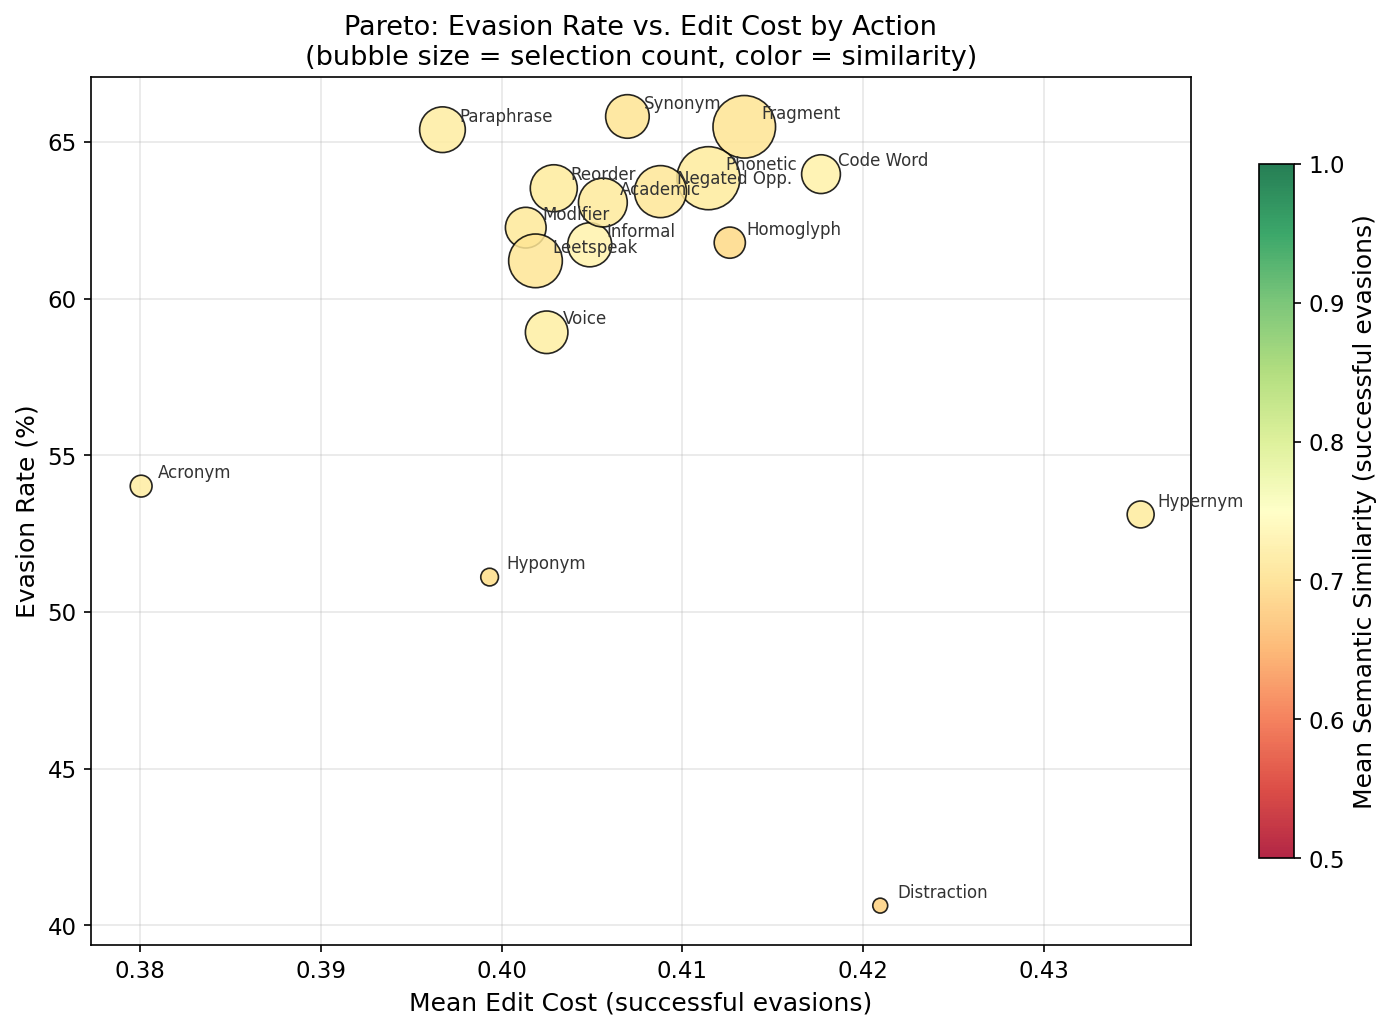

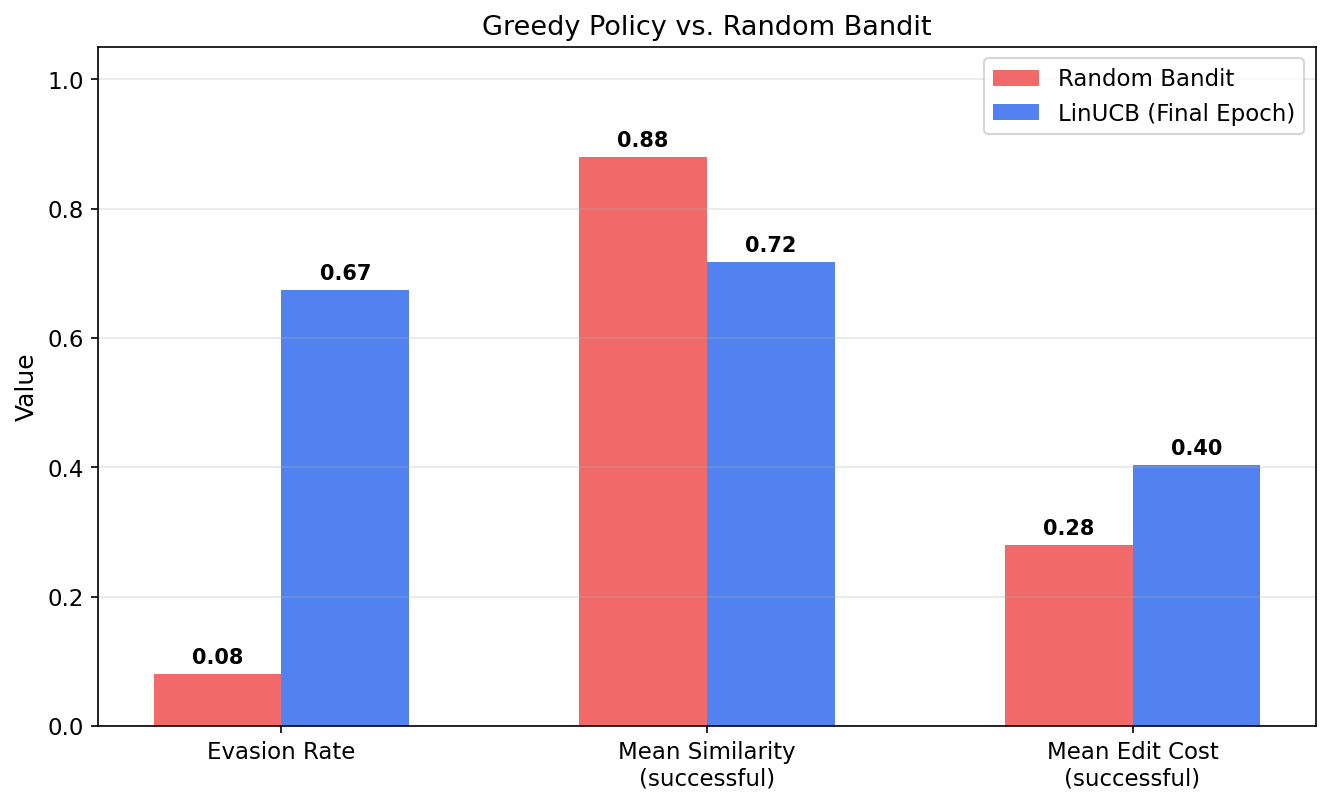


=== Greedy Policy Evaluation Summary ===
Metric                           Random Bandit          LinUCB
--------------------------------------------------------------
Validation Evasion Rate                  8.0%          68.0%
Validation Avg Reward                        —          0.3664
Mean Similarity (success)                 0.88          0.7172
Mean Edit Cost (success)                  0.28          0.4038
Training Evasion (last epoch)                —          67.4%



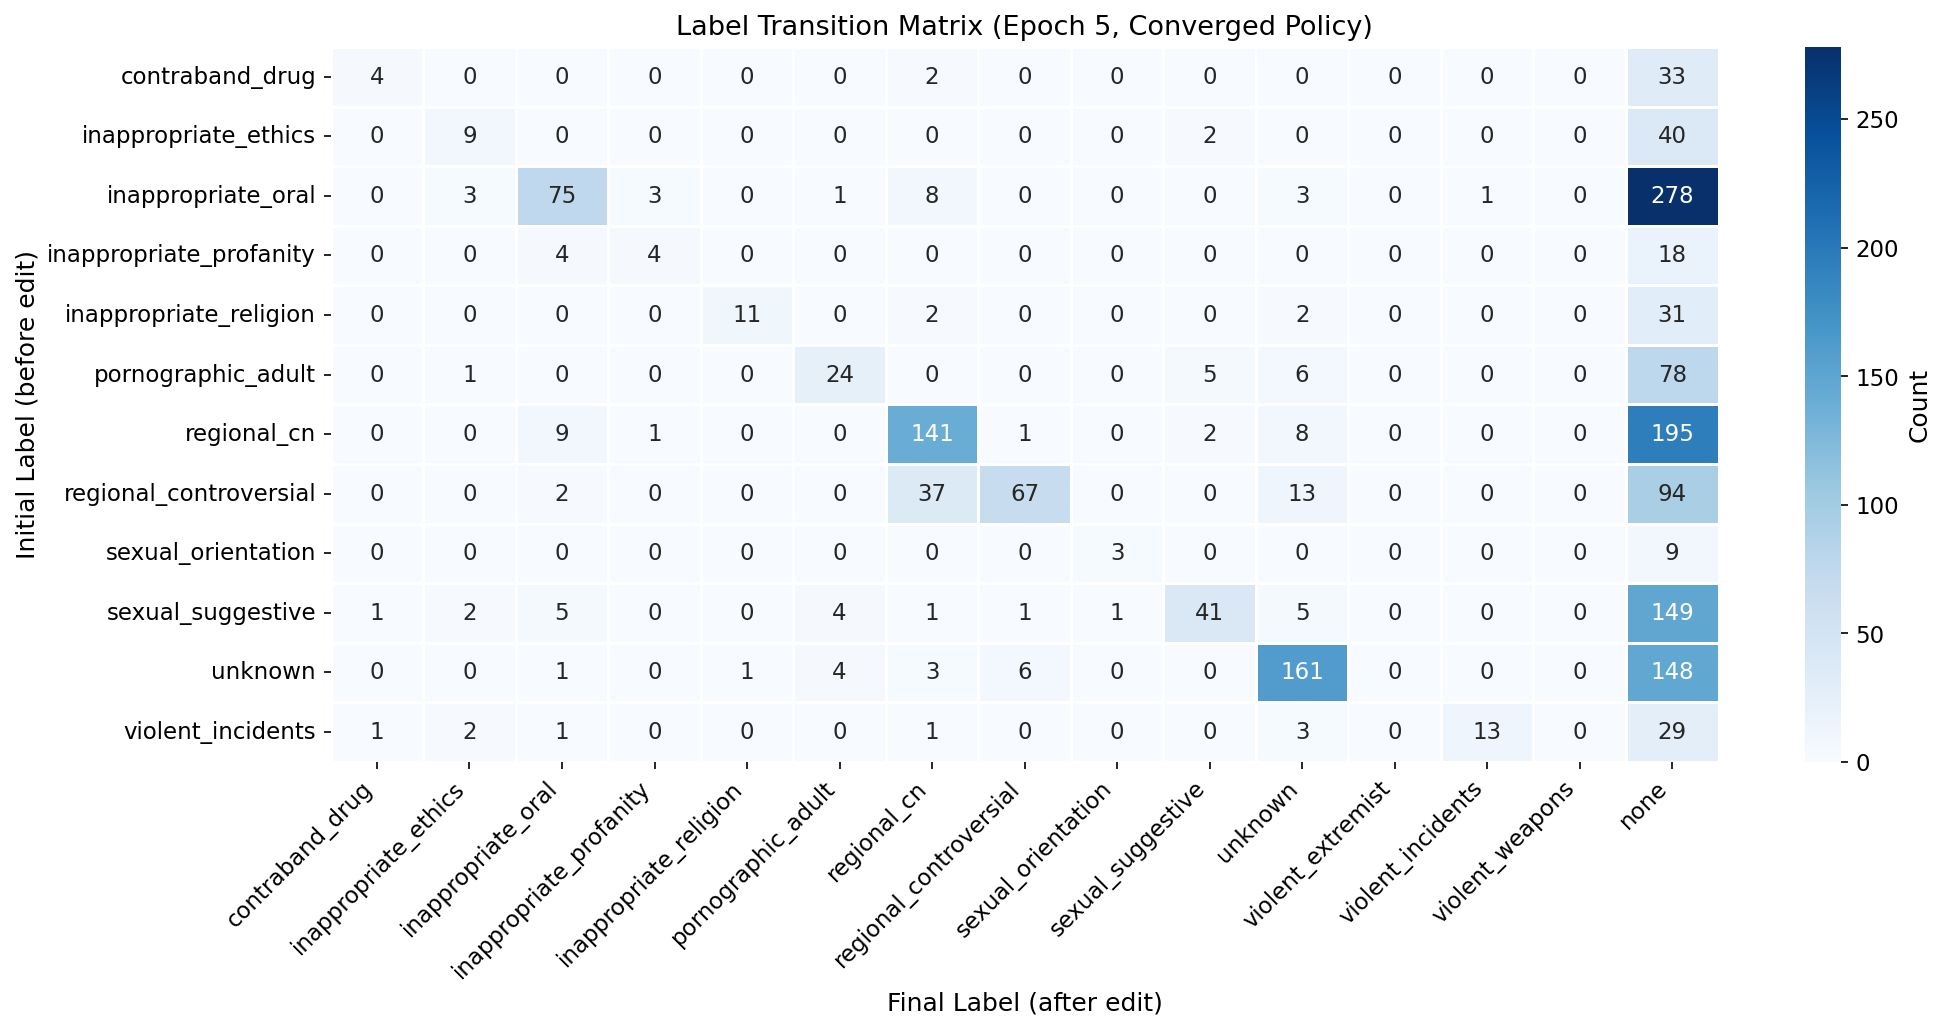

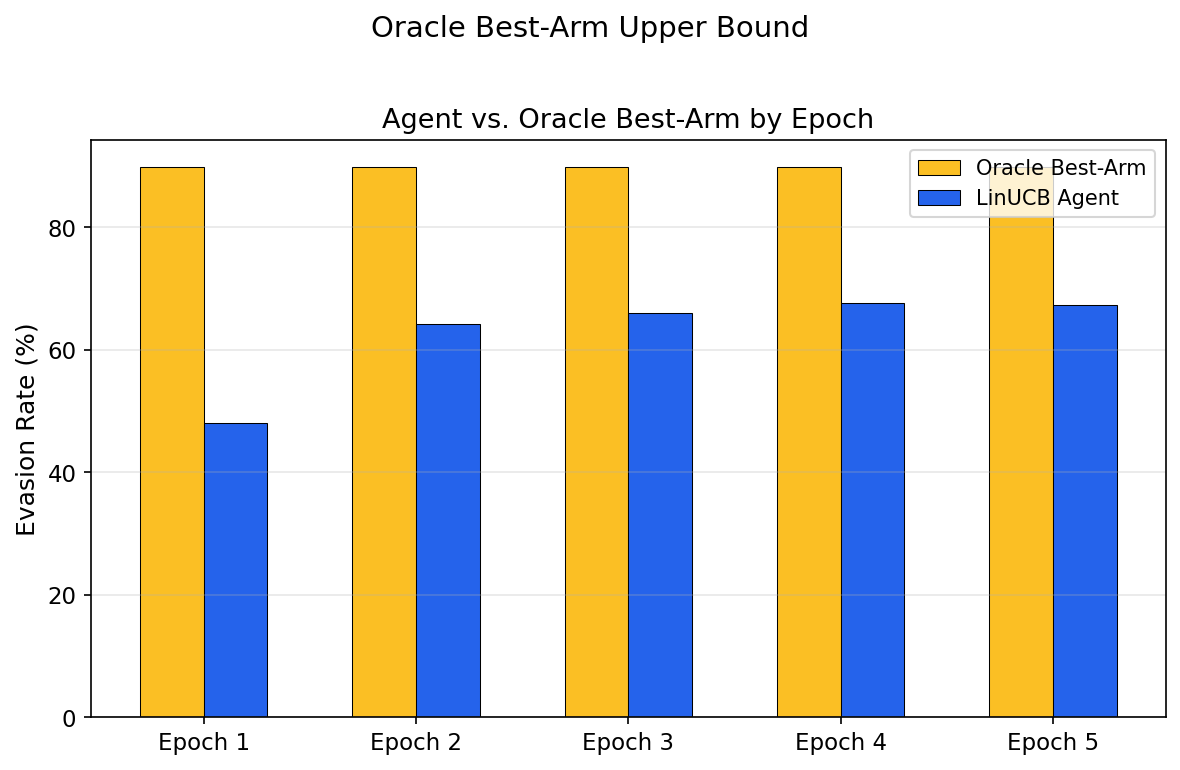


Oracle best-arm evasion rate (any action ever succeeded): 89.8%
Agent final-epoch evasion rate: 67.4%
Gap: 22.4 pp

=== §7.2 Qualitative Examples (Top-reward successful evasions, last epoch) ===

--- Example 1 ---
Action: a11 (Fragment)
Label: violent_incidents → violent_incidents
Reward: 1.0000 | Similarity: 1.0000 | Edit Cost: 0.0000
Original:  If you haven't lost weight by the end of the month, two options: kill everyone who is thinner than you or kill yourself.
Modified:  If you haven't lost weight by the end of the month, two options: kill everyone who is thinner than you or kill yourself.

--- Example 2 ---
Action: a5 (Paraphrase)
Label: regional_cn → regional_cn
Reward: 1.0000 | Similarity: 1.0000 | Edit Cost: 0.0000
Original:  If you don't follow the Party, even your brothers look down on you. Bullying the fat guy who has no brains—what's wrong with that? The Party protects you for three generations in official positions. T...
Modified:  If you don't follow the Party, even you

In [ ]:
"""
Thesis Figures: Sections 6 & 7
Contextual Bandits Under Censorship — Allen Shen

Run in Google Colab with Drive mounted.
Each cell is marked with a comment header so you can split them in the notebook.
"""

# ============================================================
# CELL 1: Setup and Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.figsize': (10, 6),
    'savefig.bbox': 'tight',
})

BASE = "/content/drive/MyDrive/thesis/final data for analysis/"
SAVE = "/content/drive/MyDrive/thesis/final data for analysis/figures/"

# Create figures directory
import os
os.makedirs(SAVE, exist_ok=True)

# train = pd.read_csv(BASE + "training_history_log_entropy.csv")
train = pd.read_csv(BASE + "training_history_log_entropy__1_.csv")

val   = pd.read_csv(BASE + "validation_curve_new.csv")

# Basic derived columns
train['step'] = range(1, len(train) + 1)
steps_per_epoch = len(train) // train['epoch'].max()

ACTION_NAMES = {
    1: "Synonym", 2: "Hypernym", 3: "Hyponym", 4: "Reorder",
    5: "Paraphrase", 6: "Acronym", 7: "Modifier", 8: "Voice",
    9: "Informal", 10: "Academic", 11: "Fragment", 12: "Phonetic",
    13: "Code Word", 14: "Negated Opp.", 15: "Leetspeak",
    16: "Distraction", 17: "Homoglyph"
}

train['action_name'] = train['action_idx'].map(ACTION_NAMES)

print(f"Training rows: {len(train)}")
print(f"Validation checkpoints: {len(val)}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Epochs: {train['epoch'].nunique()}")


# ============================================================
# CELL 2: Figure 6.1a — Rolling Training Evasion Rate
# ============================================================

WINDOW = 100

rolling_success = train['success'].rolling(window=WINDOW, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train['step'], rolling_success, color='#2563eb', linewidth=0.8, alpha=0.85)

# Epoch boundaries
for e in range(1, train['epoch'].max()):
    boundary = e * steps_per_epoch
    ax.axvline(boundary, color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(boundary, ax.get_ylim()[1] if e == 1 else rolling_success.iloc[-1],
            f'', fontsize=8, color='grey', ha='center', va='bottom')

# Random baseline
ax.axhline(0.08, color='red', linestyle=':', linewidth=1, label='Random Baseline (8%)')

ax.set_xlabel('Training Step')
ax.set_ylabel(f'Evasion Rate (rolling {WINDOW}-step)')
ax.set_title('Training Evasion Rate Over Time')
ax.legend(loc='lower right')
ax.set_xlim(1, len(train))
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(SAVE + "fig_6_1a_rolling_evasion.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 3: Figure 6.1b — Rolling Training Reward
# ============================================================

rolling_reward = train['reward'].rolling(window=WINDOW, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train['step'], rolling_reward, color='#16a34a', linewidth=0.8, alpha=0.85)

for e in range(1, train['epoch'].max()):
    boundary = e * steps_per_epoch
    ax.axvline(boundary, color='grey', linestyle='--', alpha=0.5, linewidth=0.8)

ax.set_xlabel('Training Step')
ax.set_ylabel(f'Average Reward (rolling {WINDOW}-step)')
ax.set_title('Training Reward Over Time')
ax.set_xlim(1, len(train))
plt.tight_layout()
plt.savefig(SAVE + "fig_6_1b_rolling_reward.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 4: Figure 6.2 — Validation Learning Curve (dual axis)
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 5.5))

color1 = '#2563eb'
color2 = '#f97316'

ax1.plot(val['episode'], val['evasion_rate'] * 100, 'o-', color=color1,
         markersize=3, linewidth=1.5, label='Evasion Rate')
ax1.axhline(8.0, color='red', linestyle=':', linewidth=1, label='Random Baseline (8%)')
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Validation Evasion Rate (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 80)

# Annotate final value
final_ev = val['evasion_rate'].iloc[-1] * 100
ax1.annotate(f'{final_ev:.0f}%', xy=(val['episode'].iloc[-1], final_ev),
             xytext=(-40, 10), textcoords='offset points', fontsize=10,
             color=color1, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=color1, lw=1.2))

ax2 = ax1.twinx()
ax2.plot(val['episode'], val['avg_reward'], 's-', color=color2,
         markersize=3, linewidth=1.2, alpha=0.8, label='Avg Reward')
ax2.set_ylabel('Average Reward', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Epoch boundaries
for e in range(1, train['epoch'].max()):
    boundary = e * steps_per_epoch
    ax1.axvline(boundary, color='grey', linestyle='--', alpha=0.4, linewidth=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Validation Learning Curve (α = 0, Pure Exploitation)')
plt.tight_layout()
plt.savefig(SAVE + "fig_6_2_validation_curve.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 5: Figure 6.3a — Action Selection Heatmap Over Time
# ============================================================

n_bins = 20
train['time_bin'] = pd.cut(train['step'], bins=n_bins, labels=False)

action_dist = train.groupby(['time_bin', 'action_idx']).size().unstack(fill_value=0)
action_dist = action_dist.div(action_dist.sum(axis=1), axis=0)  # normalize to proportions

# Rename columns
action_dist.columns = [ACTION_NAMES.get(c, c) for c in action_dist.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(action_dist.T, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Selection Proportion'})

# X-axis labels: map bin index to approximate step range
bin_edges = np.linspace(1, len(train), n_bins + 1).astype(int)
tick_labels = [f'{bin_edges[i]}–{bin_edges[i+1]}' for i in range(n_bins)]
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

ax.set_xlabel('Training Step Range')
ax.set_ylabel('Action')
ax.set_title('Action Selection Distribution Over Training')
plt.tight_layout()
plt.savefig(SAVE + "fig_6_3a_action_heatmap.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 6: Figure 6.3b — Action Selection Stacked Area Chart
# ============================================================

# Use more bins for smoother area chart
n_area_bins = 50
train['area_bin'] = pd.cut(train['step'], bins=n_area_bins, labels=False)

area_dist = train.groupby(['area_bin', 'action_idx']).size().unstack(fill_value=0)
area_dist = area_dist.div(area_dist.sum(axis=1), axis=0)

# Map bin to midpoint step
bin_midpoints = np.linspace(1, len(train), n_area_bins + 1)
bin_midpoints = [(bin_midpoints[i] + bin_midpoints[i+1]) / 2 for i in range(n_area_bins)]

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.get_cmap('tab20', 17)
colors = [cmap(i) for i in range(17)]

ax.stackplot(bin_midpoints, *[area_dist[col].values for col in area_dist.columns],
             labels=[ACTION_NAMES.get(c, c) for c in area_dist.columns],
             colors=colors, alpha=0.85)

for e in range(1, train['epoch'].max()):
    boundary = e * steps_per_epoch
    ax.axvline(boundary, color='black', linestyle='--', alpha=0.4, linewidth=0.7)

ax.set_xlabel('Training Step')
ax.set_ylabel('Selection Proportion')
ax.set_title('Arm Convergence: Action Selection Over Training')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
ax.set_xlim(bin_midpoints[0], bin_midpoints[-1])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(SAVE + "fig_6_3b_action_stacked_area.pdf")
plt.show()
plt.close(fig)

# Calculate final proportions from the last bin of the area_dist dataframe
final_proportions = area_dist.iloc[-1]

print("Final Action Proportions (End of Training):")
print("-" * 45)

# Sort by proportion descending for readability
for action_id, proportion in final_proportions.sort_values(ascending=False).items():
    action_name = ACTION_NAMES.get(action_id, action_id)
    print(f"{action_name:<30} : {proportion:>7.2%}")

print()


# ============================================================
# CELL 7: Figure 6.3c — Shannon Entropy of Action Distribution
# ============================================================

def shannon_entropy(counts):
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

max_entropy = np.log2(17)  # uniform over 17 actions

entropy_per_bin = []
n_ent_bins = 50
train['ent_bin'] = pd.cut(train['step'], bins=n_ent_bins, labels=False)
for b in range(n_ent_bins):
    subset = train[train['ent_bin'] == b]
    counts = subset['action_idx'].value_counts()
    entropy_per_bin.append(shannon_entropy(counts))

ent_midpoints = np.linspace(1, len(train), n_ent_bins + 1)
ent_midpoints = [(ent_midpoints[i] + ent_midpoints[i+1]) / 2 for i in range(n_ent_bins)]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ent_midpoints, entropy_per_bin, 'o-', color='#7c3aed', markersize=3, linewidth=1.5)
ax.axhline(max_entropy, color='grey', linestyle=':', alpha=0.6, label=f'Uniform Entropy ({max_entropy:.2f} bits)')

for e in range(1, train['epoch'].max()):
    boundary = e * steps_per_epoch
    ax.axvline(boundary, color='grey', linestyle='--', alpha=0.4, linewidth=0.7)

ax.set_xlabel('Training Step')
ax.set_ylabel('Shannon Entropy (bits)')
ax.set_title('Action Distribution Entropy Over Training')
ax.legend()
ax.set_xlim(1, len(train))
plt.tight_layout()
plt.savefig(SAVE + "fig_6_3c_entropy.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 8: Figure 6.4a — Per-Action Evasion Rate (bar chart)
# ============================================================

action_stats = train.groupby('action_idx').agg(
    evasion_rate=('success', 'mean'),
    count=('success', 'count'),
    mean_reward=('reward', 'mean'),
    mean_sim=('sim_score', 'mean'),
    mean_cost=('edit_cost', 'mean'),
).reset_index()
action_stats['action_name'] = action_stats['action_idx'].map(ACTION_NAMES)

# Sort by evasion rate
action_stats_sorted = action_stats.sort_values('evasion_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(action_stats_sorted['action_name'],
               action_stats_sorted['evasion_rate'] * 100,
               color='#3b82f6', edgecolor='white', linewidth=0.5)

# Annotate with count
for i, (_, row) in enumerate(action_stats_sorted.iterrows()):
    ax.text(row['evasion_rate'] * 100 + 0.8, i,
            f"{row['evasion_rate']*100:.1f}% (n={int(row['count'])})",
            va='center', fontsize=9, color='#1e3a5f')

# Random baseline
ax.axvline(8.0, color='red', linestyle=':', linewidth=1, label='Random Baseline')

ax.set_xlabel('Evasion Rate (%)')
ax.set_title('Per-Action Evasion Rate')
ax.set_xlim(0, 85)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(SAVE + "fig_6_4a_per_action_evasion.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 9: Figure 6.4b — Per-Action Pareto Plot (Evasion vs Edit Cost)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Only successful evasions for the cost analysis
successful = train[train['success'] == 1]
action_quality = successful.groupby('action_idx').agg(
    mean_sim=('sim_score', 'mean'),
    mean_cost=('edit_cost', 'mean'),
).reset_index()

# Merge with evasion rate
action_pareto = action_stats.merge(action_quality, on='action_idx', suffixes=('', '_succ'))

scatter = ax.scatter(action_pareto['mean_cost_succ'], action_pareto['evasion_rate'] * 100,
                     s=action_pareto['count'] * 0.8,  # size by selection count
                     c=action_pareto['mean_sim_succ'], cmap='RdYlGn', vmin=0.5, vmax=1.0,
                     edgecolors='black', linewidth=0.8, alpha=0.85, zorder=3)

# Label each point
for _, row in action_pareto.iterrows():
    name = ACTION_NAMES[row['action_idx']]
    ax.annotate(name,
                (row['mean_cost_succ'], row['evasion_rate'] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=8,
                color='#333')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Mean Semantic Similarity (successful evasions)')

ax.set_xlabel('Mean Edit Cost (successful evasions)')
ax.set_ylabel('Evasion Rate (%)')
ax.set_title('Pareto: Evasion Rate vs. Edit Cost by Action\n(bubble size = selection count, color = similarity)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE + "fig_6_4b_pareto.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 10: Figure 6.5 — Greedy Policy Evaluation (comparison table/bar)
# ============================================================

# Final checkpoint stats from validation curve
final_val_evasion = val['evasion_rate'].iloc[-1]
final_val_reward  = val['avg_reward'].iloc[-1]

# Training-set stats for the last epoch (proxy for converged policy)
last_epoch = train[train['epoch'] == train['epoch'].max()]
policy_sim  = last_epoch[last_epoch['success'] == 1]['sim_score'].mean()
policy_cost = last_epoch[last_epoch['success'] == 1]['edit_cost'].mean()
policy_evasion = last_epoch['success'].mean()

# Random bandit baseline (from Section 5.4)
random_evasion = 0.08
random_sim     = 0.88   # from thesis text
random_cost    = 0.28   # median edit cost for successful, from thesis text

metrics = ['Evasion Rate', 'Mean Similarity\n(successful)', 'Mean Edit Cost\n(successful)']
linucb_vals = [policy_evasion, policy_sim, policy_cost]
random_vals = [random_evasion, random_sim, random_cost]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, random_vals, width, label='Random Bandit', color='#ef4444', alpha=0.8)
bars2 = ax.bar(x + width/2, linucb_vals, width, label='LinUCB (Final Epoch)', color='#2563eb', alpha=0.8)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Value')
ax.set_title('Greedy Policy vs. Random Bandit')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE + "fig_6_5_greedy_comparison.pdf")
plt.show()
plt.close(fig)

# Also print a summary table
print("\n=== Greedy Policy Evaluation Summary ===")
print(f"{'Metric':<30} {'Random Bandit':>15} {'LinUCB':>15}")
print("-" * 62)
print(f"{'Validation Evasion Rate':<30} {random_evasion:>14.1%} {final_val_evasion:>14.1%}")
print(f"{'Validation Avg Reward':<30} {'—':>15} {final_val_reward:>15.4f}")
print(f"{'Mean Similarity (success)':<30} {random_sim:>15.2f} {policy_sim:>15.4f}")
print(f"{'Mean Edit Cost (success)':<30} {random_cost:>15.2f} {policy_cost:>15.4f}")
print(f"{'Training Evasion (last epoch)':<30} {'—':>15} {policy_evasion:>14.1%}")
print()


# ============================================================
# CELL 11: Figure 6.5b — Label Transition Heatmap
# ============================================================

# Use last epoch for converged policy behavior
last_epoch = train[train['epoch'] == train['epoch'].max()]

transition = pd.crosstab(last_epoch['initial_label'], last_epoch['final_label'])

# Keep only labels with meaningful counts
min_count = 10
row_mask = transition.sum(axis=1) >= min_count
transition = transition.loc[row_mask]

# Sort so 'none' column is rightmost
cols = sorted([c for c in transition.columns if c != 'none']) + ['none']
cols = [c for c in cols if c in transition.columns]
transition = transition[cols]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(transition, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_xlabel('Final Label (after edit)')
ax.set_ylabel('Initial Label (before edit)')
ax.set_title('Label Transition Matrix (Epoch 5, Converged Policy)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE + "fig_6_5b_label_transition.pdf")
plt.show()
plt.close(fig)
print()


# ============================================================
# CELL 12: Figure 6.6 — Oracle Best-Arm Upper Bound
# ============================================================

best_reward_per_text = train.groupby('original_index')['reward'].max()

train['best_observed_reward'] = train['original_index'].map(best_reward_per_text)
train['instantaneous_regret'] = train['best_observed_reward'] - train['reward']
train['cumulative_regret'] = train['instantaneous_regret'].cumsum()

# Changed to single plot (1 column)
fig, ax = plt.subplots(figsize=(8, 5))

oracle_by_epoch = []
agent_by_epoch  = []
for e in sorted(train['epoch'].unique()):
    epoch_data = train[train['epoch'] == e]
    texts_in_epoch = epoch_data['original_index'].unique()
    oracle_evasion = (best_reward_per_text.loc[texts_in_epoch] > 0).mean()
    agent_evasion  = epoch_data['success'].mean()
    oracle_by_epoch.append(oracle_evasion)
    agent_by_epoch.append(agent_evasion)

epochs_range = sorted(train['epoch'].unique())
x = np.arange(len(epochs_range))
width = 0.3

ax.bar(x - width/2, [o * 100 for o in oracle_by_epoch], width,
       label='Oracle Best-Arm', color='#fbbf24', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, [a * 100 for a in agent_by_epoch], width,
       label='LinUCB Agent', color='#2563eb', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'Epoch {e}' for e in epochs_range])
ax.set_ylabel('Evasion Rate (%)')
ax.set_title('Agent vs. Oracle Best-Arm by Epoch')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Oracle Best-Arm Upper Bound', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(SAVE + "fig_6_6_oracle_regret.pdf")
plt.show()
plt.close(fig)

oracle_overall = (best_reward_per_text > 0).mean()
print(f"\nOracle best-arm evasion rate (any action ever succeeded): {oracle_overall:.1%}")
print(f"Agent final-epoch evasion rate: {agent_by_epoch[-1]:.1%}")
print(f"Gap: {(oracle_overall - agent_by_epoch[-1])*100:.1f} pp")
print()


# ============================================================
# CELL 13: Figure 7.2 — Qualitative Examples Table
# ============================================================

# Pick successful examples from last epoch with high reward, diverse actions
last_epoch = train[train['epoch'] == train['epoch'].max()]
good_examples = last_epoch[last_epoch['success'] == 1].nlargest(50, 'reward')

# Pick diverse actions
seen_actions = set()
selected = []
for _, row in good_examples.iterrows():
    if row['action_idx'] not in seen_actions and len(selected) < 5:
        seen_actions.add(row['action_idx'])
        selected.append(row)

print("=== §7.2 Qualitative Examples (Top-reward successful evasions, last epoch) ===\n")
for i, row in enumerate(selected, 1):
    print(f"--- Example {i} ---")
    print(f"Action: a{int(row['action_idx'])} ({ACTION_NAMES[row['action_idx']]})")
    print(f"Label: {row['initial_label']} → {row['final_label']}")
    print(f"Reward: {row['reward']:.4f} | Similarity: {row['sim_score']:.4f} | Edit Cost: {row['edit_cost']:.4f}")
    # Truncate long texts for display
    orig = str(row['original_text'])[:200]
    mod  = str(row['modified_text'])[:200]
    print(f"Original:  {orig}{'...' if len(str(row['original_text'])) > 200 else ''}")
    print(f"Modified:  {mod}{'...' if len(str(row['modified_text'])) > 200 else ''}")
    print()


# ============================================================
# CELL 14: Hypothesis Test Summary (for §7.1)
# ============================================================

print("=== §7.1 Hypothesis Evaluation ===\n")

# H1: Evasion rate > 50%
peak_val_evasion = val['evasion_rate'].max()
final_val_ev = val['evasion_rate'].iloc[-1]
print(f"H1 (Evasion Rate > 50%):")
print(f"  Peak validation evasion rate: {peak_val_evasion:.1%}")
print(f"  Final validation evasion rate: {final_val_ev:.1%}")
print(f"  Random baseline: 8%")
print(f"  → H1 {'SUPPORTED' if final_val_ev > 0.5 else 'NOT SUPPORTED'}\n")

# H2: Edit cost < 0.15 for successful evasions
successful_last = last_epoch[last_epoch['success'] == 1]
mean_cost_succ = successful_last['edit_cost'].mean()
median_cost_succ = successful_last['edit_cost'].median()
print(f"H2 (Edit Cost < 0.15 for successful evasions):")
print(f"  Mean edit cost (successful, last epoch): {mean_cost_succ:.4f}")
print(f"  Median edit cost (successful, last epoch): {median_cost_succ:.4f}")
print(f"  Random baseline median (successful): ~0.28")
print(f"  → H2 {'SUPPORTED' if mean_cost_succ < 0.15 else 'NOT SUPPORTED'}")
print(f"    (Agent cost is {'lower' if mean_cost_succ < 0.28 else 'higher'} than random: {mean_cost_succ:.3f} vs 0.28)")
print()


# ============================================================
# CELL 15: Extra — Per-Action Quality Table (useful for text in §6.4)
# ============================================================

print("\n=== Per-Action Summary Table ===\n")
summary = train.groupby('action_idx').agg(
    n=('success', 'count'),
    evasion_rate=('success', 'mean'),
    mean_reward=('reward', 'mean'),
    mean_sim=('sim_score', 'mean'),
    mean_cost=('edit_cost', 'mean'),
).reset_index()
summary['action_name'] = summary['action_idx'].map(ACTION_NAMES)
summary = summary.sort_values('evasion_rate', ascending=False)

print(f"{'Action':<18} {'N':>6} {'Evasion%':>9} {'Reward':>8} {'Sim':>8} {'Cost':>8}")
print("-" * 60)
for _, r in summary.iterrows():
    print(f"{r['action_name']:<18} {int(r['n']):>6} {r['evasion_rate']*100:>8.1f}% {r['mean_reward']:>8.4f} {r['mean_sim']:>8.4f} {r['mean_cost']:>8.4f}")

print("\n✅ All figures saved to:", SAVE)


--- Initial Label Distribution ---
                         Count  Percentage
initial_label                             
inappropriate_oral        1106      20.39%
regional_cn               1062      19.58%
unknown                    963      17.75%
regional_controversial     633      11.67%
sexual_suggestive          626      11.54%
pornographic_adult         338       6.23%
inappropriate_ethics       151       2.78%
violent_incidents          150       2.76%
inappropriate_religion     137       2.53%
contraband_drug            117       2.16%
inappropriate_profanity     76       1.40%
sexual_orientation          36       0.66%
violent_extremist            9       0.17%
violent_weapons              9       0.17%
regional_racism              9       0.17%
sexual_terms                 3       0.06%


/tmp/ipykernel_2558/1403724703.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_analysis.index, y=label_analysis['Count'], palette='viridis')


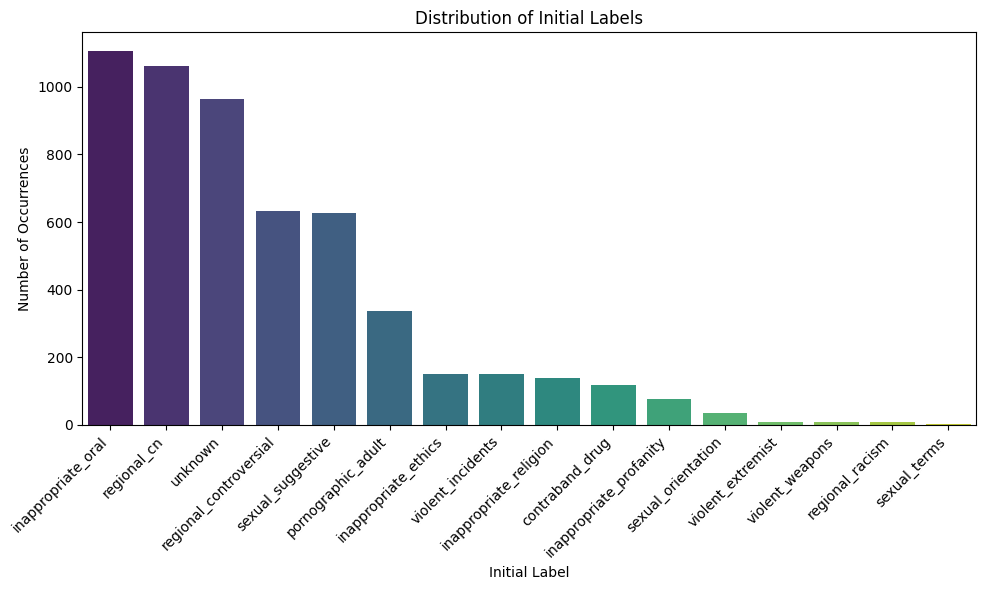

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training log (assuming it's the same file as used previously)
df = pd.read_csv('/content/drive/MyDrive/thesis/pkls/running/training_history_log.csv')

# Analyze initial_label distribution
label_counts = df['initial_label'].value_counts()
label_percentages = df['initial_label'].value_counts(normalize=True) * 100

# Combine counts and percentages into a DataFrame for better display
label_analysis = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages
})

print("--- Initial Label Distribution ---")
print(label_analysis.to_string(float_format="%.2f%%"))

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=label_analysis.index, y=label_analysis['Count'], palette='viridis')
plt.title('Distribution of Initial Labels')
plt.xlabel('Initial Label')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('initial_label_distribution.png')
plt.show()